# **Necessary Imports**

In [5]:
!pip install keras_tuner
!pip install scikeras

In [6]:
# Numerical arrays
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Neural network
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split, StratifiedKFold
import keras_tuner

# Data Preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Model evaluation
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                              accuracy_score, precision_recall_curve)

# Hyperparameter tuning
from keras_tuner import RandomSearch

import shap
from google.colab import drive
drive.mount('/content/drive')

# Hide warnings
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


# 1. **Data Loading and Splitting**

In [7]:
# Reading the data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer-telco-churn/data/cleaned/cleaned_data.csv')

In [8]:
# remove gender and unnamed column since they are not needed
df = df.drop(["customerID", "gender"], axis=1)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == "Yes" else 0)

In [9]:
# Seperate independent and dependent variables
X = df.drop('Churn', axis=1)
y = df['Churn']

In [10]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # equal proportions of each class

In [11]:
# Get categorical (nominal + ordinal), numerical features for later preprocessing
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns.drop('Contract')  # Exclude the ordinal column
ordinal_feature = ['Contract']  # Contracts get better from Month-to-month to One year to Two year

# **2. Create Preprocessing Pipeline**

In [12]:
# numerical
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())    # standard scaler for neural network
])

# Categorical (excluding ordinal)
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore')) # encode nominal features
])

# Ordinal feature
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[
        ['Month-to-month', 'One year', 'Two year']
    ]))
])

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_feature),
        ('num', numerical_transformer, numerical_features)
    ]
)

In [13]:
def clean_feature_names(feature_names):
    """
    Clean feature names by removing transformer prefixes
    """
    cleaned_names = []

    for name in feature_names:
        # Remove transformer prefixes
        if name.startswith('cat__'):
            name = name[5:]  # Remove 'cat__'
        elif name.startswith('ord__'):
            name = name[5:]  # Remove 'ord__'
        elif name.startswith('remainder__'):
            name = name[11:]  # Remove 'remainder__'
        elif name.startswith('num__'):
            name = name[5:]

        # Replace underscores with spaces for better readability
        name = name.replace('_', ' ')

        # Capitalize each word
        name = ' '.join(word.capitalize() for word in name.split())

        cleaned_names.append(name)

    return cleaned_names

In [14]:
# Fit the preprocessor
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [15]:
feature_names_raw = preprocessor.get_feature_names_out()
feature_names = clean_feature_names(feature_names_raw)

# **3. Feature Selection with Mutual Information**

In [16]:
# Comoute mi scores
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

In [17]:
mi_df = pd.DataFrame({
    'Feature': feature_names,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

In [18]:
mi_df.head(20)

,Feature,MI Score
36,Contract,0.097501
38,Tenure,0.066324
21,Techsupport No,0.061834
12,Onlinesecurity No,0.057240
34,Paymentmethod Electronic Check,0.053044
39,Monthlycharges,0.047010
15,Onlinebackup No,0.045106
10,Internetservice Fiber Optic,0.044302
40,Totalcharges,0.039633
13,Onlinesecurity No Internet Service,0.037612


In [19]:
# Select the top 20 features only
selector = SelectKBest(score_func=mutual_info_classif, k=20)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# **4. Creating the Neural Network**

In [20]:
def create_nn(input_dim,
              hidden_layers,
              dropout_rate,
              learning_rate,
              l2_reg):
  """
  Used to create the neural network with layers, dropout, batch norm and regularization
  """
  model = tf.keras.models.Sequential()

  # Input layer
  model.add(tf.keras.layers.Input(shape=(input_dim, )))

  # Add hidden layers
  for i, neurons in enumerate(hidden_layers):
    model.add(tf.keras.layers.Dense(
        neurons,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
        name=f'hidden_layer_{i+1}'
    ))
    model.add(tf.keras.layers.BatchNormalization(name=f'batch_norm_{i+1}'))

    # dropout for regularization
    model.add(tf.keras.layers.Dropout(dropout_rate, name=f'dropout_{i+1}'))


  # Output layer
  model.add(tf.keras.layers.Dense(1, activation='sigmoid', name='output_layer'))

  # Compile model
  optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  model.compile(
      optimizer=optimizer,
      loss='binary_crossentropy',
      metrics=['accuracy',
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall'),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR')  # precision-recall prc
      ]
  )

  return model

In [21]:
# Get the dimension required for creating the model
input_dim = X_train_selected.shape[1]

# Create the model
neural_network = create_nn(
    input_dim=input_dim,
    hidden_layers=[128,64,32],
    dropout_rate=0.3,
    learning_rate=0.001,
    l2_reg=0.001
)

In [22]:
# Summary of the created model
neural_network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_3                    │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [23]:
def get_callbacks(patience=15):
  """
  To get the callbacks for early stopping
  """
  early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=patience,    # if it does not improve, then stop after patience epochs
    restore_best_weights=True,  # return to the best model without ending at the last
    verbose=1,
    mode='max'    # treats higher values as improvements
  )

  return early_stopping


In [24]:
# Receive the callbacks
callbacks = get_callbacks()

In [25]:
# Handle class imbalance

class_weights = compute_class_weight(
    'balanced',   # treat the minority class as more important
    classes=np.unique(y_train),   # exact order class labels
    y=y_train   # frequencies calculated here
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}  # returned a numpy array

# **5. Training the Neural Network**

In [26]:
# Train the network
batch_size = 32
epochs = 100
validation_split = 0.2

trained_model = neural_network.fit(
    X_train_selected,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    callbacks=callbacks,
    class_weight=class_weight_dict, # handle imbalanced data
    verbose=0
)

Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 18.


# **6. Evaluating the Neural Network**

In [27]:
# visualize training history
def visualize_history(history):
  """
  Used to visualize the training history of the model
  """

  fig, axes = plt.subplots(2, 3, figsize=(18,10))

  # loss
  axes[0, 0].plot(history.history['loss'], label='Training loss')
  axes[0, 0].plot(history.history['val_loss'], label='Validation loss')
  axes[0, 0].set_title('Model Loss')
  axes[0, 0].set_xlabel('Epoch')
  axes[0, 0].set_ylabel('Loss')
  axes[0, 0].legend()
  axes[0, 0].grid(True, alpha=0.3)

  # accuracy
  axes[0, 1].plot(history.history['accuracy'], label='Training accuracy')
  axes[0, 1].plot(history.history['val_accuracy'], label='Validation accuracy')
  axes[0, 1].set_title('Model Accuracy')
  axes[0, 1].set_xlabel('Epoch')
  axes[0, 1].set_ylabel('Accuracy')
  axes[0, 1].legend()
  axes[0, 1].grid(True, alpha=0.3)

  # AUC
  axes[0, 2].plot(history.history['auc'], label='Training AUC')
  axes[0, 2].plot(history.history['val_auc'], label='Validation AUC')
  axes[0, 2].set_title('ROC-AUC')
  axes[0, 2].set_xlabel('Epoch')
  axes[0, 2].set_ylabel('AUC')
  axes[0, 2].legend()
  axes[0, 2].grid(True, alpha=0.3)

  # precision
  axes[1, 0].plot(history.history['precision'], label='Training precision')
  axes[1, 0].plot(history.history['val_precision'], label='Validation precision')
  axes[1, 0].set_title('Model Precision')
  axes[1, 0].set_xlabel('Epoch')
  axes[1, 0].set_ylabel('Precision')
  axes[1, 0].legend()
  axes[1, 0].grid(True, alpha=0.3)

  # recall
  axes[1, 1].plot(history.history['recall'], label='Training recall')
  axes[1, 1].plot(history.history['val_recall'], label='Validation recall')
  axes[1, 1].set_title('Model Recall')
  axes[1, 1].set_xlabel('Epoch')
  axes[1, 1].set_ylabel('Recall')
  axes[1, 1].legend()
  axes[1, 1].grid(True, alpha=0.3)

  plt.tight_layout()
  fig.delaxes(axes[1, 2])
  plt.show()



In [28]:
def plot_ks_chart(y_true, y_pred_proba, model_name):
  """
  Plots KS Chart for binary classification of churn
  """

  # Calculate KS Statistic
  fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
  ks_values = tpr - fpr
  ks_statistic = np.max(ks_values)
  ks_idx = np.argmax(ks_values)
  ks_threshold = thresholds[ks_idx]

  # Create dataframe for plotting
  df_ks = pd.DataFrame({
      'Thresholds': thresholds,
      'TPR': tpr,
      'FPR': fpr,
      'KS': ks_values
  })

  # Plot
  plt.figure(figsize=(10,6))
  sns.lineplot(x='Thresholds', y='TPR', data=df_ks, label='True Positive Rate (TPR)', color='blue')
  sns.lineplot(x='Thresholds', y='FPR', data=df_ks, label='False Positive Rate (FPR)', color='red')

  # Shade the KS region
  plt.fill_between(df_ks['Thresholds'], df_ks['TPR'], df_ks['FPR'],
                   where=(df_ks['TPR'] >= df_ks['FPR']),
                   color='gray', alpha=0.2, interpolate=True)

  # Makr KS point
  plt.scatter(ks_threshold, tpr[ks_idx], color='green', s=50, label=f'KS Point ({ks_statistic:.3f})')
  plt.scatter(ks_threshold, fpr[ks_idx], color='green', s=50)

  # Style the plot
  plt.title(f"KS Chart - {model_name}", fontsize=14)
  plt.xlabel("Thresholds")
  plt.ylabel("Cumulative Percentage")
  plt.xlim([0,1])
  plt.ylim([0,1])
  plt.grid(True)
  plt.legend()
  plt.show()

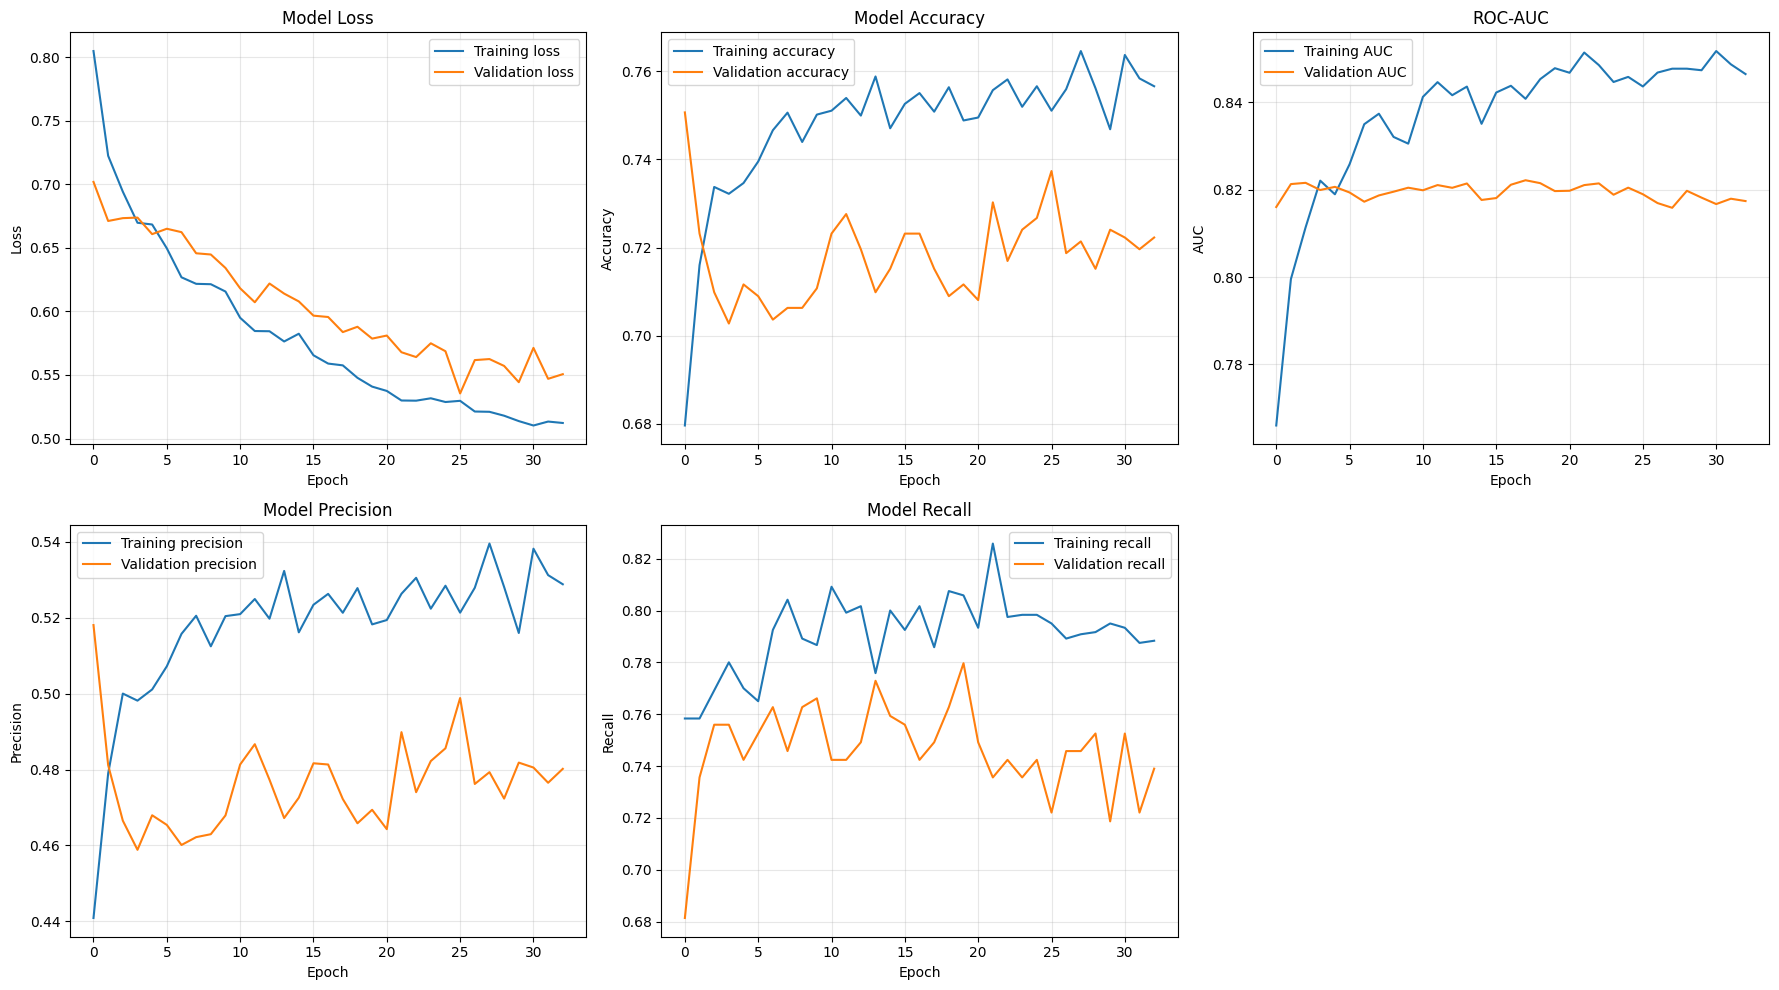

In [29]:
visualize_history(trained_model)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


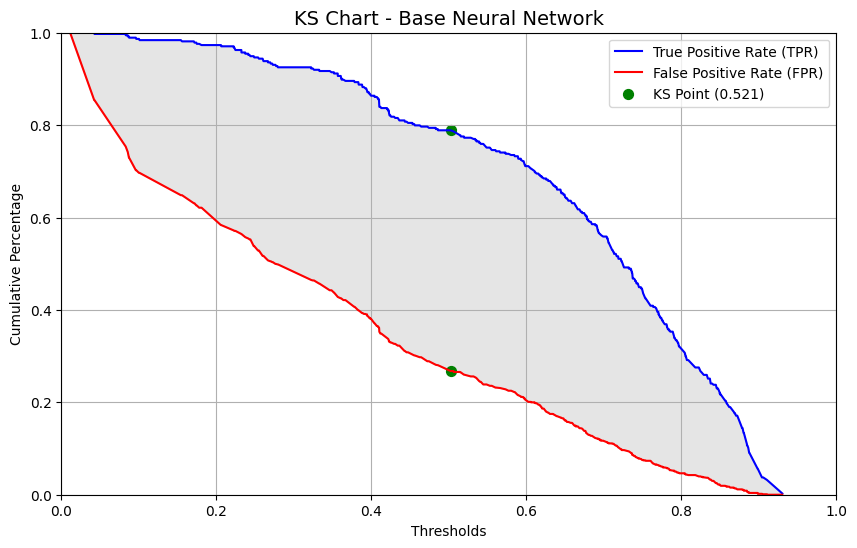

In [30]:
plot_ks_chart(y_test, neural_network.predict(X_test_selected), "Base Neural Network")

In [31]:
def evaluate_nn(model, X_test, y_test, threshold=0.5):
  """
  Used to evaluate the neural network model using a threshold
  """
  y_pred_prob = model.predict(X_test)
  y_predictions = (y_pred_prob > threshold).astype(int)

  print(classification_report(y_test, y_predictions, target_names=['No churn', 'Churn']))
  print("AUC:", roc_auc_score(y_test, y_pred_prob))

  # confusion matrix
  cm = confusion_matrix(y_test, y_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)

  # Display the confusion matrix
  disp.plot()
  plt.show()

In [32]:
def plot_tpr_fpr(y_test, y_pred_prob):
  """
  Plot ROC Curves
  """
  fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_prob)

  precision, recall, threshold_pr = precision_recall_curve(y_test, y_pred_prob)

  fig, axes = plt.subplots(1, 2, figsize=(10,6))

  # ROC Curve
  axes[0].plot(fpr, tpr, color='blue', lw=2, label='ROC Curve')
  axes[0].set_xlabel('False Positive Rate (FPR)')
  axes[0].set_ylabel('True Positive Rate (TPR)')
  axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')
  axes[0].legend(loc='lower right')
  axes[0].grid(alpha=0.5)

  # Precision recall
  axes[1].plot(recall, precision, color='green', lw=2, label='PR Curve')
  axes[1].set_xlabel('Recall')
  axes[1].set_ylabel('Precision')
  axes[1].set_title('Precision-Recall Curve')
  axes[1].legend(loc='lower left')
  axes[1].grid(alpha=0.5)

  plt.tight_layout()

  plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    No churn       0.91      0.73      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

AUC: 0.8387080523909167


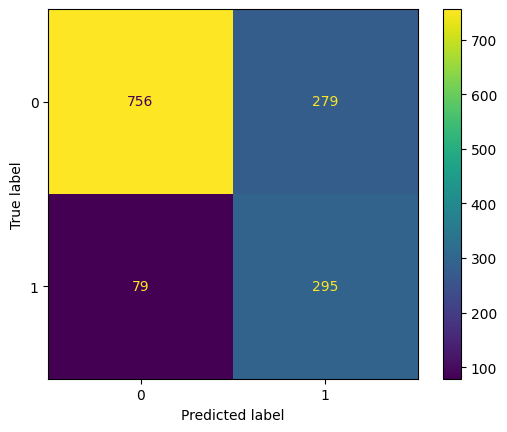

In [33]:
evaluate_nn(neural_network, X_test_selected, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    No churn       0.93      0.62      0.74      1035
       Churn       0.45      0.86      0.59       374

    accuracy                           0.68      1409
   macro avg       0.69      0.74      0.67      1409
weighted avg       0.80      0.68      0.70      1409

AUC: 0.8387080523909167


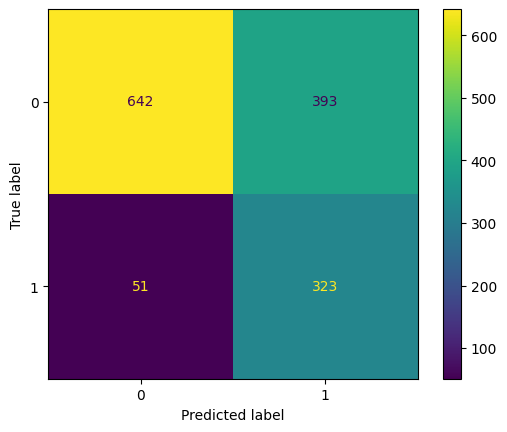

In [34]:
evaluate_nn(neural_network, X_test_selected, y_test, threshold=0.4)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    No churn       0.95      0.51      0.67      1035
       Churn       0.41      0.93      0.57       374

    accuracy                           0.62      1409
   macro avg       0.68      0.72      0.62      1409
weighted avg       0.81      0.62      0.64      1409

AUC: 0.8387080523909167


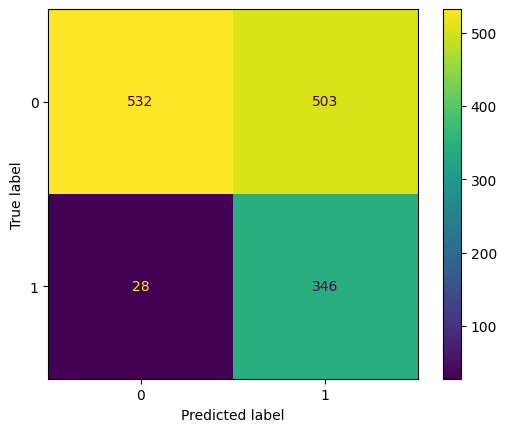

In [35]:
evaluate_nn(neural_network, X_test_selected, y_test, threshold=0.3)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


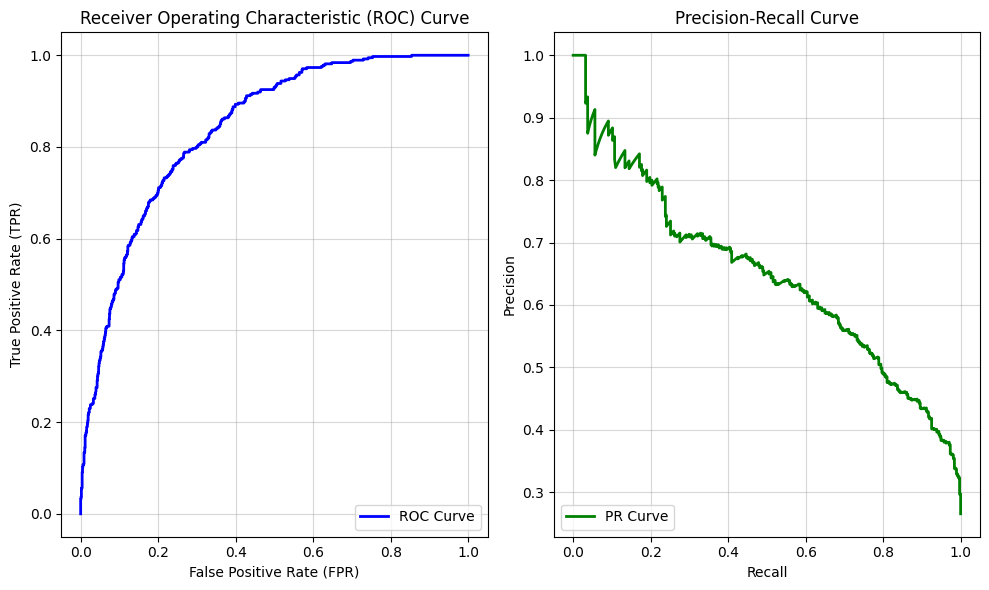

In [36]:
plot_tpr_fpr(y_test, neural_network.predict(X_test_selected))

# **7. Hyperparameter Tuning**

In [37]:
input_dim = X_train_selected.shape[1]

def tune(parameter):
  """
  Used to tune the neural network
  """
  global input_dim
  model = keras.Sequential()
  model.add(tf.keras.layers.Input(shape=(input_dim, ))) # input_dim for number of features

  # Tune number of layers
  for i in range(parameter.Int('num_layers', 1, 3)): # try 1 to 3 hidden layers (different amounts may be underfitting/overfitting)
    model.add(tf.keras.layers.Dense(
        units=parameter.Int(f'units_{i}', min_value=32, max_value=256, step=32),

        # relu to prevent vanising gradients and suited for hidden layers
        activation='relu',

        # Prevent overfitting
        kernel_regularizer=tf.keras.regularizers.l2(parameter.Float('l2', 1e-5, 1e-1, sampling='log'))
    ))
    model.add(tf.keras.layers.Dropout(parameter.Float('dropout', 0.1, 0.5, step=0.1)))

    # Normalize output of previous layers
    model.add(tf.keras.layers.BatchNormalization())

  model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

  model.compile(

                # Tune learning rate with log values
      optimizer=tf.keras.optimizers.Adam(
          learning_rate=parameter.Float('learning_rate', 1e-4, 1e-2, sampling='log')
      ),
      loss='binary_crossentropy', # for binrary classification
      metrics=['accuracy',
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall'),
      tf.keras.metrics.AUC(name='auc')] # better for imbalanced data than accuracy
  )
  return model

In [38]:
# Run hyperparameter search
tuner = RandomSearch(
    tune, # function used
    objective='val_auc',  # optimizing f1 into the maximum
    max_trials=10,    # test upto 10 different hyperparameter combinations
    executions_per_trial=2, # each trial run twice and average
    directory='tuner_results' # best model saved here
)

In [39]:
tuner.search(
    X_train_selected,
    y_train,
    epochs=30,
    validation_data=(X_test_selected, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=5,
            restore_best_weights=True, # return back to the best model
            mode='max'
        )]
)

Trial 10 Complete [00h 00m 31s]
val_auc: 0.832676500082016

Best val_auc So Far: 0.842553436756134
Total elapsed time: 00h 06m 45s


In [40]:
# Get the best hyperparameters
best_hyper_parameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyper parameters:\n")
best_hyper_parameters.values

Best hyper parameters:



{'num_layers': 2,
 'units_0': 160,
 'l2': 0.019050903180579355,
 'dropout': 0.4,
 'learning_rate': 0.0005869024141704971,
 'units_1': 256}

In [41]:
# Get the best layers
print("Best number of layers:", best_hyper_parameters.get('num_layers'))

Best number of layers: 2


In [42]:
for i in range(best_hyper_parameters.get('num_layers')):
    print(f"Best units in layer {i}:", best_hyper_parameters.get(f'units_{i}'))
    print("Best dropout rate:", best_hyper_parameters.get('dropout'))
    print("Best L2:", best_hyper_parameters.get('l2'))
    print("Best learning rate:", best_hyper_parameters.get('learning_rate'))

Best units in layer 0: 160
Best dropout rate: 0.4
Best L2: 0.019050903180579355
Best learning rate: 0.0005869024141704971
Best units in layer 1: 256
Best dropout rate: 0.4
Best L2: 0.019050903180579355
Best learning rate: 0.0005869024141704971


# **8. Training the Best Model**

In [43]:
# Build the best model
best_model = tuner.hypermodel.build(best_hyper_parameters)

In [44]:
# Train the best model
history = best_model.fit(
    X_train_selected,
    y_train,
    epochs=100,  # more epochs now
    batch_size=32,
    validation_data=(X_test_selected, y_test),
    callbacks=[get_callbacks()]
)

Epoch 1/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6813 - auc: 0.7354 - loss: 4.1758 - precision: 0.4325 - recall: 0.6491 - val_accuracy: 0.7672 - val_auc: 0.8313 - val_loss: 2.2800 - val_precision: 0.7949 - val_recall: 0.1658
Epoch 2/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7798 - auc: 0.7979 - loss: 2.0216 - precision: 0.5790 - recall: 0.5523 - val_accuracy: 0.7686 - val_auc: 0.8310 - val_loss: 1.4317 - val_precision: 0.7727 - val_recall: 0.1818
Epoch 3/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7619 - auc: 0.7742 - loss: 1.3639 - precision: 0.5379 - recall: 0.4608 - val_accuracy: 0.7835 - val_auc: 0.8300 - val_loss: 1.0495 - val_precision: 0.7717 - val_recall: 0.2620
Epoch 4/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7735 - auc: 0.8031 - loss: 1.0107 - precision: 0.5766 - recall: 0.4778 - val_accuracy: 0.7892 - val_auc: 0.8268 - val_loss: 0.8343 - val_precision: 0.6486 - val_recall: 0.4492
Epoch 5/100
177/177 ━━━━━━━

# **9. Comparison and Evaluation**

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

    No churn       0.83      0.92      0.87      1035
       Churn       0.68      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

AUC: 0.8407889638068666


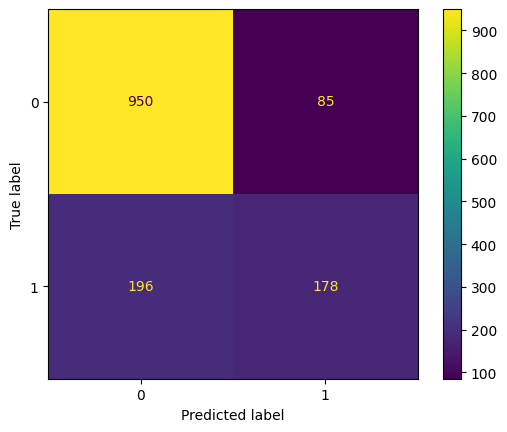

In [45]:
evaluate_nn(best_model, X_test_selected, y_test)  # threshold of 0.5

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    No churn       0.87      0.85      0.86      1035
       Churn       0.61      0.64      0.62       374

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.79      0.80      1409

AUC: 0.8407889638068666


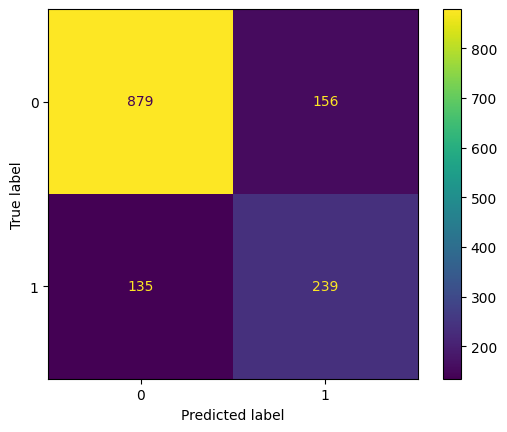

In [46]:
evaluate_nn(best_model, X_test_selected, y_test, threshold=0.4)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    No churn       0.90      0.74      0.81      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

AUC: 0.8407889638068666


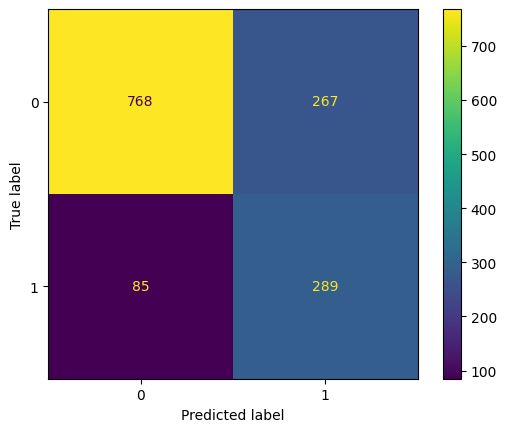

In [47]:
evaluate_nn(best_model, X_test_selected, y_test, threshold=0.3)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


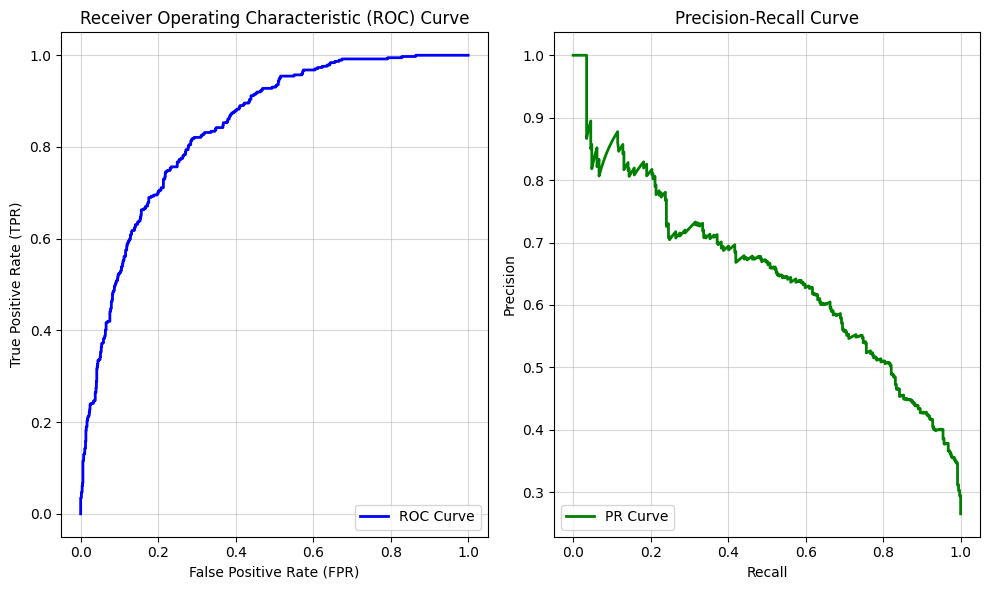

In [48]:
plot_tpr_fpr(y_test, best_model.predict(X_test_selected))

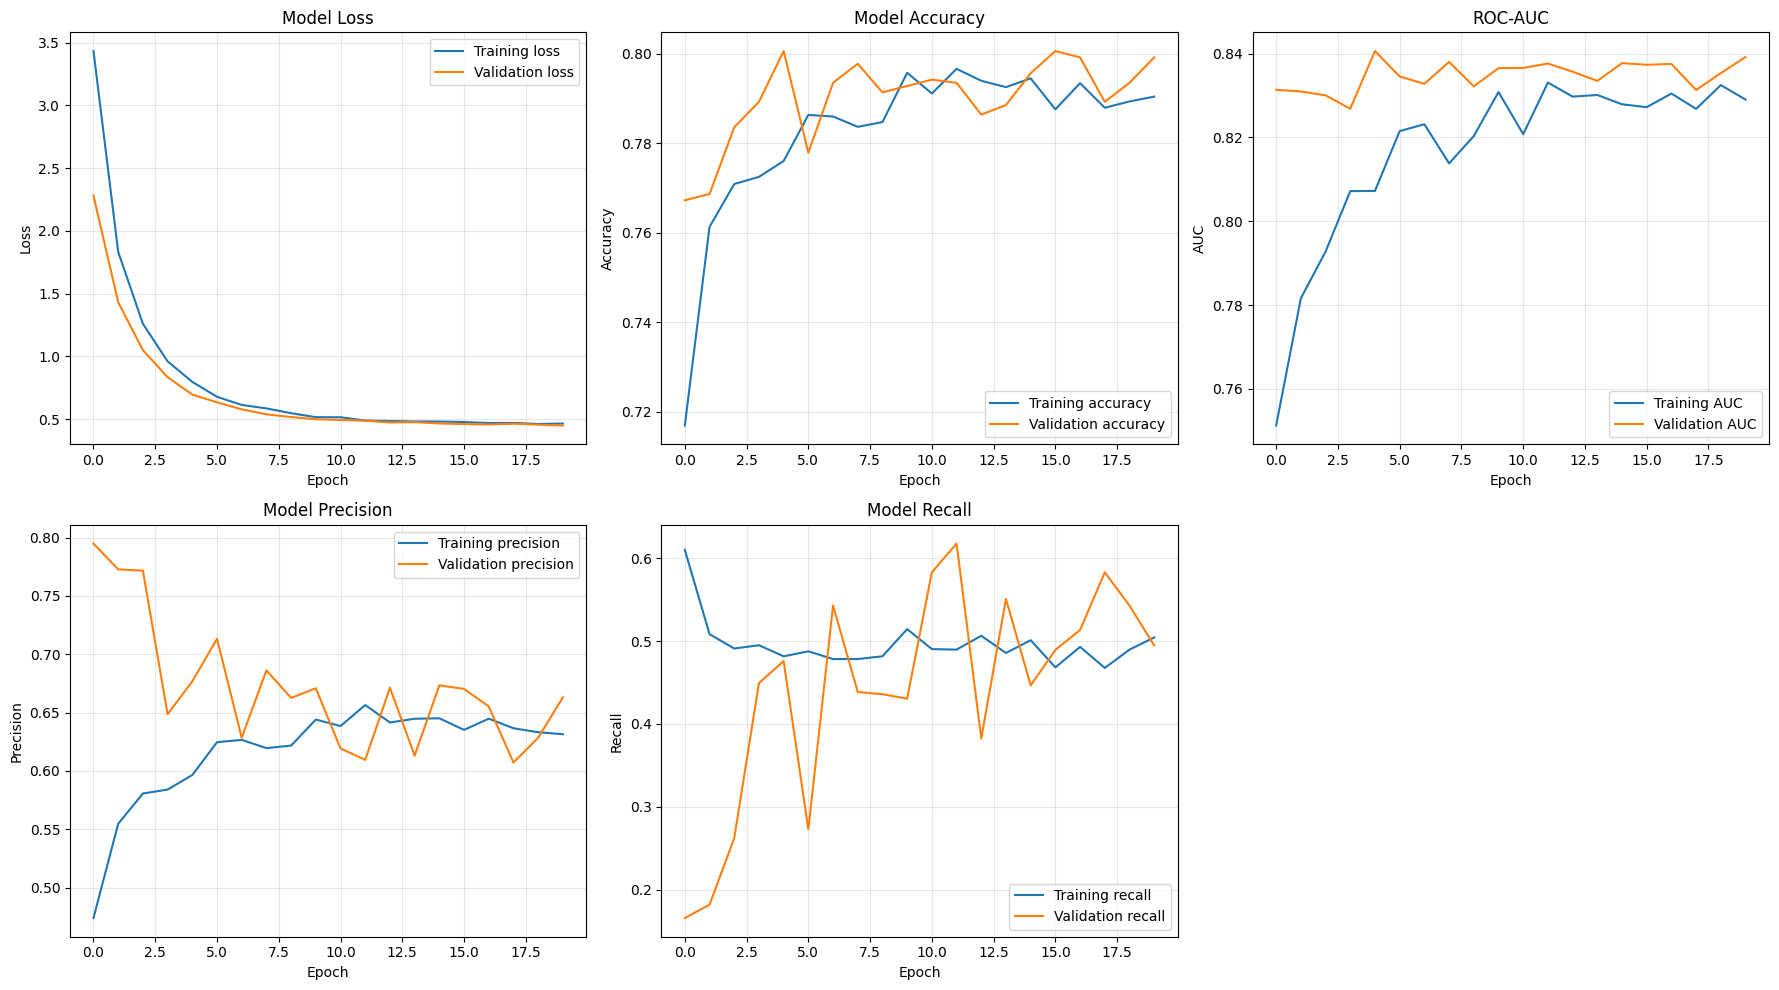

In [49]:
visualize_history(history)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


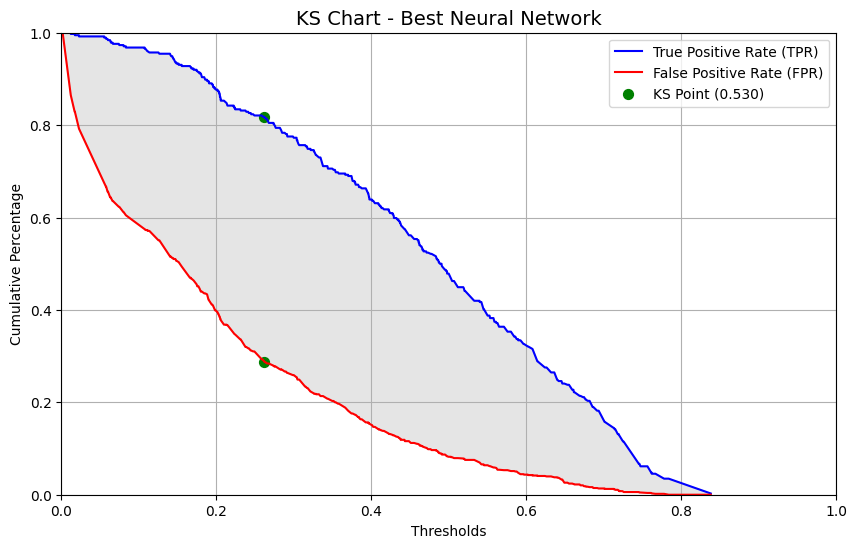

In [50]:
plot_ks_chart(y_test, best_model.predict(X_test_selected), "Best Neural Network")

# **10. Neural Network Interpretation with SHAP**

In [51]:
# Choose background for shap
background = shap.sample(X_train_selected, 100)

In [52]:
# Create the explainer
explainer = shap.KernelExplainer(best_model, background)

In [53]:
# generate shap values
shap_values = explainer.shap_values(X_test_selected[:200])  # subset for speed

  0%|          | 0/200 [00:00<?, ?it/s]

In [54]:
selected_mask = selector.get_support()

In [55]:
# Get the previously selected names
selected_feature_names = np.array(feature_names)[selected_mask]

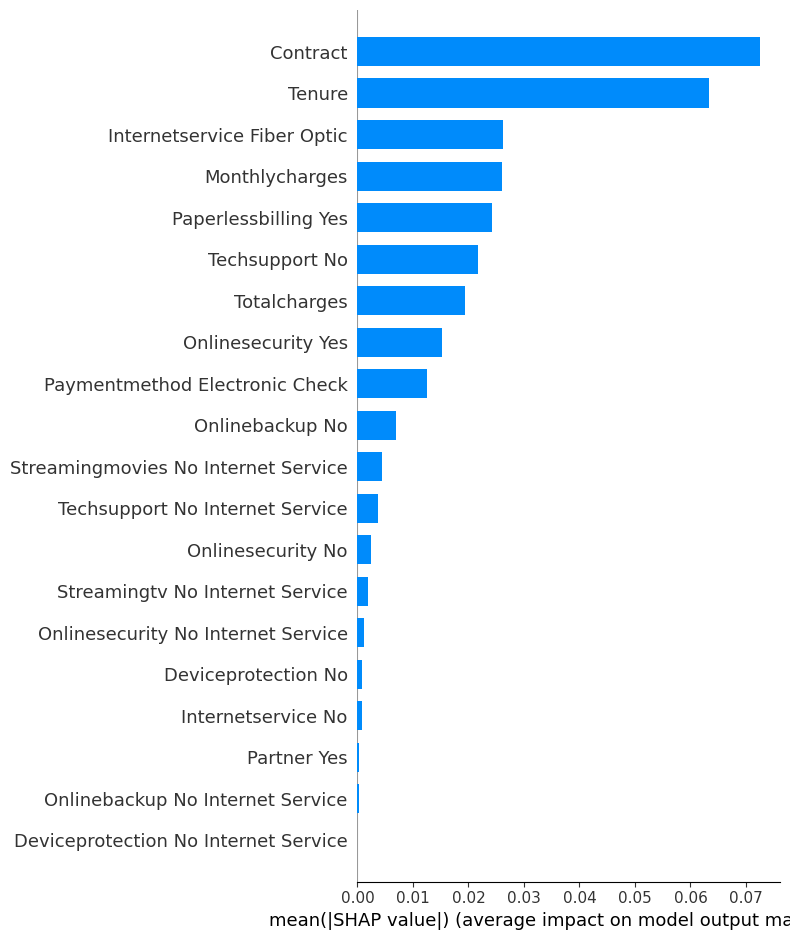

<Figure size 640x480 with 0 Axes>

In [56]:
 # Summary plot of feature importance
shap.summary_plot(shap_values[:, :, 0], X_test_selected[:200],
                  feature_names=selected_feature_names,
                  plot_type='bar')
plt.tight_layout()
plt.show()

In [57]:
# forceplot for predictions
shap.initjs()
shap.force_plot(explainer.expected_value[0],
                shap_values[0].flatten(),
                X_test_selected[0],
                feature_names=selected_feature_names)

# **11. Save the Best Model**

In [58]:
# save model
best_model.save('neural_model.h5')
